# 1.0 — Setup & Imports
Mount Google Drive and import all required standard, third-party, and ML libraries.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Standard library
import io
import json
import os
import random
import time
from pathlib import Path

# Third-party – data / viz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
)
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

sns.set_style("whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 2.0 — Configuration
All hyper-parameters, paths, and architecture configs are defined here. Change values in this single cell to reconfigure the whole notebook.

In [3]:
# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────
MODEL_DIR   = Path("/content/drive/My Drive/Classification/dofa/models")
RESULTS_DIR = Path("/content/drive/My Drive/Classification/dofa/results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR    = RESULTS_DIR / "training_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR     = RESULTS_DIR / "scene_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR   = Path("/content/drive/My Drive/Classification/data")
DATA_FILE  = DATA_DIR / "data.csv"
LABEL_FILE = DATA_DIR / "ref.csv"

# ── Dataset geometry ──────────────────────────────────────────────────
H, W, B    = 330, 307, 6          # height, width, bands
PATCH_SIZE  = 9
INNER_PATCH = 3                   # tokenisation patch size for Hiera_ViT / Fusion

# ── Train / val / test splits ─────────────────────────────────────────
TRAIN_PERCENT          = 0.75
VAL_SPLIT_FROM_TRAIN   = 0.20

# ── Training ──────────────────────────────────────────────────────────
BATCH_SIZE    = 128
EPOCHS        = 100
LEARNING_RATE = 3e-4
DROPOUT_RATE  = 0.25
CAPACITY_PRESET = "dofa_hiera_arch"

TRAIN_CFG = {
    "label_smoothing": 0.05,
    "weight_decay":    1e-4,
    "clipnorm":        1.0,
    "cosine_alpha":    0.05,
}

# ── Sensor metadata (Landsat TM/ETM+ 6 reflective bands: B,G,R,NIR,SWIR1,SWIR2) ─
# Central wavelengths in micrometres. Consumed by the DOFA-style hypernetwork so
# the spectral embedding is conditioned on sensor physics rather than band index
# (Xiong et al., 2024, "Neural Plasticity-Inspired Foundation Model" — DOFA).
BAND_WAVELENGTHS_UM = [0.485, 0.56, 0.66, 0.83, 1.65, 2.22]

# ── Architecture configs ──────────────────────────────────────────────
DOFA_CFG = {
    "embed_dim":   96,
    "hyper_hidden": 64,
    "dense_units": [256, 128, 64],
}

HIERA_CFG = {
    "stage_dims":   [128, 256],
    "stage_blocks": [2, 2],
    "num_heads":    4,
    "mlp_ratio":    2,
}

FUSION_CFG = {
    "dofa_embed_dim":     96,
    "hiera_stage_dims":   [128, 256],
    "hiera_stage_blocks": [2, 2],
    "hiera_num_heads":    4,
    "fusion_dim":         256,
    "head_units":         [256, 128, 64],
}

# Fallback configs used when Colab runs out of memory
HIERA_FALLBACK_CFG = {
    "stage_dims": [96, 192], "stage_blocks": [1, 2], "num_heads": 4, "mlp_ratio": 2,
}
FUSION_FALLBACK_CFG = {
    "dofa_embed_dim":     64,
    "hiera_stage_dims":   [96, 192],
    "hiera_stage_blocks": [1, 2],
    "hiera_num_heads":    4,
    "fusion_dim":         192,
    "head_units":         [192, 96, 64],
}

# ── Visualisation palette ─────────────────────────────────────────────
CLASS_COLOR_BASE = [
    "#0000FF", "#00FF00", "#FF0000", "#00FFFF", "#FF00FF",
    "#FFFF00", "#A52A2A", "#FFA500", "#7FFF00", "#8A2BE2",
]
BACKGROUND_COLOR  = "#000000"
VIS_EXCEL_PATH    = VIS_DIR / "initial_classification_maps.xlsx"

print("Data file:    ", DATA_FILE)
print("Label file:   ", LABEL_FILE)
print("Model dir:    ", MODEL_DIR)
print("Results dir:  ", RESULTS_DIR)
print("Plot dir:     ", PLOT_DIR)
print("Arch preset:  ", CAPACITY_PRESET)

Data file:     /content/drive/My Drive/Classification/data/data.csv
Label file:    /content/drive/My Drive/Classification/data/ref.csv
Model dir:     /content/drive/My Drive/Classification/dofa/models
Results dir:   /content/drive/My Drive/Classification/dofa/results
Plot dir:      /content/drive/My Drive/Classification/dofa/results/training_plots
Arch preset:   dofa_hiera_arch


# 3.0 — Data Loading & Preprocessing
Load the raw multispectral CSV files, apply per-band min-max normalisation, extract labelled patches, and create stratified train / val / test splits.

## 3.1 — Loading and patch extraction helpers

In [4]:
def load_multispectral_6band(data_path, label_path, height, width, bands):
    """Load multispectral data and reference labels; normalise each band to [0, 1]."""
    x = pd.read_csv(data_path).to_numpy(dtype=np.float32).reshape(height, width, bands)
    y = pd.read_csv(label_path).to_numpy(dtype=np.int32).reshape(height, width)

    x_norm = np.empty_like(x, dtype=np.float32)
    for b in range(bands):
        band     = x[:, :, b]
        band_min = np.min(band)
        band_max = np.max(band)
        denom    = max(band_max - band_min, 1e-8)
        x_norm[:, :, b] = (band - band_min) / denom

    return x_norm, y


def extract_labeled_patches(x, y, patch_size=9):
    """Extract (patch_size × patch_size) spatial patches around every labelled pixel."""
    pad   = patch_size // 2
    x_pad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="edge")

    coords  = np.argwhere(y > 0)
    patches = np.empty((coords.shape[0], patch_size, patch_size, x.shape[-1]), dtype=np.float32)
    labels  = np.empty((coords.shape[0],), dtype=np.int32)

    for i, (r, c) in enumerate(coords):
        patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        labels[i]  = int(y[r, c]) - 1  # convert class IDs to 0..C-1

    return patches, labels, coords

## 3.2 — Load data and create splits

In [5]:
x_img, y_img = load_multispectral_6band(DATA_FILE, LABEL_FILE, H, W, B)
X, y, coords = extract_labeled_patches(x_img, y_img, PATCH_SIZE)

num_classes = int(np.unique(y).size)
input_shape = (PATCH_SIZE, PATCH_SIZE, B)

print("x_img:", x_img.shape, "  y_img:", y_img.shape)
print("Labelled samples:", X.shape[0])
print("Patch tensor:    ", X.shape)
print("Num classes:     ", num_classes)

x_img: (330, 307, 6)   y_img: (330, 307)
Labelled samples: 17239
Patch tensor:     (17239, 9, 9, 6)
Num classes:      7


In [6]:
# Stratified split used by all three models (DOFA_Spectral, Hiera_ViT, DOFA_Hiera_Fusion)
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X, y,
    train_size=TRAIN_PERCENT,
    random_state=SEED,
    stratify=y,
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SPLIT_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_full,
)

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat   = keras.utils.to_categorical(y_val,   num_classes)
y_test_cat  = keras.utils.to_categorical(y_test,  num_classes)

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape,   y_val.shape)
print("Test: ", x_test.shape,  y_test.shape)

Train: (10343, 9, 9, 6) (10343,)
Val:   (2586, 9, 9, 6) (2586,)
Test:  (4310, 9, 9, 6) (4310,)


# 4.0 — Model Definitions
Defines three single-head architectures: a DOFA-inspired spectral network, a Hiera-inspired hierarchical Vision Transformer, and a DOFA+Hiera attention-fusion model. Custom Keras layers are registered for serialisation.

## 4.1 — Shared custom Keras layers (PatchExtractor, PatchPositionEncoder, DOFAWavelengthEmbed) and the shared transformer block

In [7]:
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    """Extract non-overlapping spatial patches from an image tensor."""

    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches     = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        batch       = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim   = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    """Project patches to embedding dim and add learned positional embeddings."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches      = num_patches
        self.projection_dim   = projection_dim
        self.projection       = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_patches": self.num_patches, "projection_dim": self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class DOFAWavelengthEmbed(layers.Layer):
    """DOFA-inspired dynamic patch embedding.

    A small hypernetwork maps each band's central wavelength to a projection
    weight vector, so the resulting per-pixel spectral embedding is generated
    from sensor physics rather than a fixed, band-index-specific kernel. This
    is what lets the same layer generalise across sensors with different band
    counts/wavelengths (Xiong et al., 2024 — DOFA; used as the spectral
    encoder in LandSegmenter, Liu et al., 2026).
    """

    def __init__(self, embed_dim, wavelengths_um, hidden_dim=64, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim      = embed_dim
        self.hidden_dim     = hidden_dim
        self.wavelengths_um = list(wavelengths_um)

    def build(self, input_shape):
        self.wavelengths = tf.constant(self.wavelengths_um, dtype=tf.float32)  # (bands,)
        self.hyper_fc1 = layers.Dense(self.hidden_dim, activation="gelu", name=f"{self.name}_hyper1")
        self.hyper_fc2 = layers.Dense(self.hidden_dim, activation="gelu", name=f"{self.name}_hyper2")
        self.hyper_out = layers.Dense(self.embed_dim, name=f"{self.name}_hyper_out")
        self.bias = self.add_weight(name="dofa_bias", shape=(self.embed_dim,), initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, patches):
        w      = tf.reshape(self.wavelengths, [-1, 1])                    # (bands, 1)
        kernel = self.hyper_out(self.hyper_fc2(self.hyper_fc1(w)))        # (bands, embed_dim)
        return tf.einsum("bhwc,ce->bhwe", patches, kernel) + self.bias

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "embed_dim": self.embed_dim,
            "wavelengths_um": self.wavelengths_um,
            "hidden_dim": self.hidden_dim,
        })
        return cfg


def transformer_block(x, num_heads, projection_dim, mlp_dim, dropout_rate, name_prefix):
    """Standard pre-LN transformer block with multi-head attention and a GELU MLP."""
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    y = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim,
        dropout=dropout_rate, name=f"{name_prefix}_mha",
    )(y, y)
    x = layers.Add(name=f"{name_prefix}_add1")([y, x])

    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(x)
    y = layers.Dense(mlp_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(y)
    y = layers.Dense(projection_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(y)
    return layers.Add(name=f"{name_prefix}_add2")([y, x])

## 4.2 — DOFA-inspired spectral embedding network (replaces the AlexNet CNN)

In [8]:
def dofa_spectral_branch(inputs, cfg, dropout_rate, name_prefix="dofa"):
    """DOFA-style spectral branch: wavelength-conditioned embedding, globally
    pooled and passed through a light MLP head (mirrors "freeze DOFA, extract
    features, train a small head" — the standard, fastest way to use a frozen
    foundation model on a small labelled set).
    """
    x = DOFAWavelengthEmbed(
        cfg["embed_dim"], BAND_WAVELENGTHS_UM,
        hidden_dim=cfg["hyper_hidden"], name=f"{name_prefix}_embed",
    )(inputs)
    x = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)
    for i, units in enumerate(cfg["dense_units"], start=1):
        x = layers.Dense(units, activation="gelu", name=f"{name_prefix}_fc{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop{i}")(x)
    return x


def build_dofa_spectral(input_shape, num_classes, dropout_rate=0.25, cfg=None):
    """Build a DOFA-inspired spectral classifier: dynamic, wavelength-conditioned
    patch embedding (Xiong et al., 2024) followed by a light MLP head. Replaces
    the AlexNet CNN as the "pure spectral" baseline.
    """
    cfg = cfg or DOFA_CFG
    inputs  = keras.Input(shape=input_shape)
    x       = dofa_spectral_branch(inputs, cfg, dropout_rate, name_prefix="dofa")
    outputs = layers.Dense(num_classes, activation="softmax", name="dofa_logits")(x)
    return keras.Model(inputs, outputs, name="DOFA_Spectral")

## 4.3 — Hiera-inspired hierarchical Vision Transformer (replaces GFNet)

In [9]:
def hiera_merge_tokens(x, token_side, dim_out, name_prefix):
    """Patch-merging step between Hiera stages: reshape tokens back to a grid,
    2x2-pool (with edge padding if the side is odd), then project channels up.
    This is the pooling-attention idea behind SAM2's Hiera backbone — spatial
    resolution shrinks and channel width grows between stages, all with plain
    Keras layers (fully serialisable, no custom layer needed here).
    """
    x   = layers.Reshape((token_side, token_side, -1), name=f"{name_prefix}_to_grid")(x)
    pad = token_side % 2
    if pad:
        x = layers.ZeroPadding2D(padding=((0, pad), (0, pad)), name=f"{name_prefix}_pad")(x)
    x = layers.AveragePooling2D(pool_size=2, name=f"{name_prefix}_pool")(x)
    x = layers.Conv2D(dim_out, 1, activation="gelu", name=f"{name_prefix}_proj")(x)
    new_side = (token_side + pad) // 2
    x = layers.Reshape((new_side * new_side, dim_out), name=f"{name_prefix}_to_tokens")(x)
    return x, new_side


def hiera_spatial_branch(inputs, inner_patch, cfg, dropout_rate, name_prefix="hiera"):
    """Hiera-inspired hierarchical transformer branch: tokenise, run transformer
    blocks per stage, and patch-merge between stages (Ravi et al., 2024 —
    SAM2/Hiera). Unlike a plain ViT, spatial tokens are progressively pooled
    rather than pruned via a [CLS] token, so the final representation comes
    from global average pooling over the last stage's tokens.
    """
    token_side  = inputs.shape[1] // inner_patch
    num_patches = token_side * token_side

    x = PatchExtractor(inner_patch, name=f"{name_prefix}_patch_extractor")(inputs)
    x = PatchPositionEncoder(num_patches, cfg["stage_dims"][0], name=f"{name_prefix}_patch_encoder")(x)
    x = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop0")(x)

    for stage_idx, (dim, n_blocks) in enumerate(zip(cfg["stage_dims"], cfg["stage_blocks"]), start=1):
        prefix = f"{name_prefix}_stage{stage_idx}"
        if stage_idx > 1:
            x, token_side = hiera_merge_tokens(x, token_side, dim, name_prefix=f"{prefix}_merge")
        for b in range(n_blocks):
            x = transformer_block(
                x, num_heads=cfg["num_heads"], projection_dim=dim,
                mlp_dim=dim * cfg["mlp_ratio"], dropout_rate=dropout_rate,
                name_prefix=f"{prefix}_blk{b + 1}",
            )

    x = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_final_ln")(x)
    x = layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    x = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop_final")(x)
    return x


def build_hiera_vit(input_shape, num_classes, inner_patch=3, dropout_rate=0.25, cfg=None):
    """Build a Hiera-inspired hierarchical Vision Transformer classifier.
    Replaces GFNet as the "pure spatial" baseline.
    """
    cfg = cfg or HIERA_CFG
    inputs  = keras.Input(shape=input_shape)
    x       = hiera_spatial_branch(inputs, inner_patch, cfg, dropout_rate, name_prefix="hiera")
    outputs = layers.Dense(num_classes, activation="softmax", name="hiera_logits")(x)
    return keras.Model(inputs, outputs, name="Hiera_ViT")

## 4.4 — DOFA + Hiera attention-fusion model (replaces the ViT/U-Net head)

In [10]:
def attention_fusion(feat_a, feat_b, dim, dropout_rate, name_prefix):
    """Attention-based Fusion Module (AFM): project both branches to a shared
    dimension, then gate each with its own sigmoid attention computed from the
    concatenated pair before summing — a squeeze-excite-style analogue of the
    feature/position attention fusion in LandSegmenter (Liu et al., 2026,
    Eq. 4-5), adapted here to two already-pooled feature vectors rather than
    spatial feature maps.
    """
    proj_a = layers.Dense(dim, name=f"{name_prefix}_proj_a")(feat_a)
    proj_b = layers.Dense(dim, name=f"{name_prefix}_proj_b")(feat_b)

    concat = layers.Concatenate(name=f"{name_prefix}_concat")([proj_a, proj_b])
    attn   = layers.Dense(dim // 2, activation="relu", name=f"{name_prefix}_attn_hidden")(concat)
    attn_a = layers.Dense(dim, activation="sigmoid", name=f"{name_prefix}_attn_a")(attn)
    attn_b = layers.Dense(dim, activation="sigmoid", name=f"{name_prefix}_attn_b")(attn)

    gated_a = layers.Multiply(name=f"{name_prefix}_gated_a")([proj_a, attn_a])
    gated_b = layers.Multiply(name=f"{name_prefix}_gated_b")([proj_b, attn_b])

    fused = layers.Add(name=f"{name_prefix}_fused_add")([gated_a, gated_b])
    fused = layers.LayerNormalization(name=f"{name_prefix}_fused_ln")(fused)
    fused = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop")(fused)
    return fused


def build_dofa_hiera_fusion(input_shape, num_classes, inner_patch=3, dropout_rate=0.25, cfg=None):
    """Build the full LandSegmenter-inspired classifier: a DOFA spectral branch
    and a Hiera spatial branch combined through an attention-based fusion
    module (AFM). Replaces the ViT/U-Net single-head model.
    """
    cfg = cfg or FUSION_CFG
    inputs = keras.Input(shape=input_shape)

    dofa_vec = dofa_spectral_branch(
        inputs,
        {"embed_dim": cfg["dofa_embed_dim"], "hyper_hidden": 64, "dense_units": [cfg["fusion_dim"]]},
        dropout_rate, name_prefix="fusion_dofa",
    )
    hiera_vec = hiera_spatial_branch(
        inputs, inner_patch,
        {
            "stage_dims": cfg["hiera_stage_dims"], "stage_blocks": cfg["hiera_stage_blocks"],
            "num_heads": cfg["hiera_num_heads"], "mlp_ratio": 2,
        },
        dropout_rate, name_prefix="fusion_hiera",
    )

    fused = attention_fusion(dofa_vec, hiera_vec, cfg["fusion_dim"], dropout_rate, name_prefix="afm")

    y = fused
    for i, units in enumerate(cfg["head_units"], start=1):
        y = layers.Dense(units, activation="gelu", name=f"fusion_head_{i}")(y)
        y = layers.Dropout(dropout_rate, name=f"fusion_head_drop_{i}")(y)

    outputs = layers.Dense(num_classes, activation="softmax", name="fusion_logits")(y)
    return keras.Model(inputs, outputs, name="DOFA_Hiera_Fusion")

# 5.0 — Training & Evaluation Helpers
Optimiser factory, learning-rate schedule, calibration metrics (Brier score, ECE), and the main `train_save_evaluate` function.

## 5.1 — Calibration metrics

In [11]:
def multiclass_brier_score(y_onehot, y_prob):
    """Compute the multiclass Brier score (mean squared error over probability vectors)."""
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def expected_calibration_error(y_true, y_prob, n_bins=15):
    """Compute Expected Calibration Error (ECE) with equal-width confidence bins."""
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    correct     = (predictions == y_true).astype(np.float32)
    bin_edges   = np.linspace(0.0, 1.0, n_bins + 1)
    ece         = 0.0

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        in_bin = (confidences >= lo) & (confidences <= hi if i == n_bins - 1 else confidences < hi)
        prop   = np.mean(in_bin)
        if prop > 0:
            ece += np.abs(np.mean(correct[in_bin]) - np.mean(confidences[in_bin])) * prop

    return float(ece)

## 5.2 — Optimiser factory

In [12]:
def make_optimizer(num_train_samples):
    """Build an AdamW optimiser with a cosine-decay learning-rate schedule."""
    steps_per_epoch = int(np.ceil(num_train_samples / BATCH_SIZE))
    decay_steps     = max(1, steps_per_epoch * EPOCHS)
    lr_schedule     = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=decay_steps,
        alpha=TRAIN_CFG["cosine_alpha"],
    )
    return keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=TRAIN_CFG["weight_decay"],
        clipnorm=TRAIN_CFG["clipnorm"],
    )

## 5.3 — Main training, saving, and evaluation function

In [13]:
def train_save_evaluate(model_name, model_builder, capacity_tag="max"):
    """Compile, train, save (best + final), and evaluate a single-head model.

    Returns a metrics dict, per-class classification report, confusion matrix,
    and the raw Keras history dict.
    """
    tf.keras.backend.clear_session()
    model      = model_builder()
    best_path  = MODEL_DIR / f"{model_name}_best.keras"
    final_path = MODEL_DIR / f"{model_name}_final.keras"

    # All three models (DOFA_Spectral, Hiera_ViT, DOFA_Hiera_Fusion) share the
    # same AdamW + cosine-decay + label-smoothing recipe.
    model.compile(
        optimizer=make_optimizer(len(x_train)),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=TRAIN_CFG["label_smoothing"]),
        metrics=["accuracy"],
    )
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(best_path), monitor="val_loss",
            mode="min", save_best_only=True, verbose=1,
        ),
    ]
    x_tr, y_tr           = x_train, y_train_cat
    x_va, y_va           = x_val,   y_val_cat
    x_te, y_te, y_te_cat = x_test, y_test, y_test_cat
    x_eval, y_eval, y_eval_cat = x_val, y_val, y_val_cat
    fit_shuffle           = True

    train_start = time.perf_counter()
    history_obj = model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )
    train_time_sec = float(time.perf_counter() - train_start)

    epochs_ran = int(len(history_obj.history.get("loss", [])))
    if epochs_ran != EPOCHS:
        print(f"WARNING: {model_name} ran {epochs_ran} epochs, expected {EPOCHS}.")
    else:
        print(f"{model_name} completed full training: {epochs_ran}/{EPOCHS} epochs.")

    model.save(final_path)

    y_eval_prob = model.predict(x_eval, batch_size=BATCH_SIZE, verbose=0)
    y_test_prob = model.predict(x_te,   batch_size=BATCH_SIZE, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    report = classification_report(y_te, y_test_pred, output_dict=True, zero_division=0)
    cm     = confusion_matrix(y_te, y_test_pred)

    row = {
        "model":            model_name,
        "capacity_tag":     capacity_tag,
        "test_accuracy":    float(accuracy_score(y_te, y_test_pred)),
        "kappa":            float(cohen_kappa_score(y_te, y_test_pred)),
        "macro_f1":         float(f1_score(y_te, y_test_pred, average="macro")),
        "weighted_f1":      float(f1_score(y_te, y_test_pred, average="weighted")),
        "val_nll":          float(log_loss(y_eval, y_eval_prob, labels=np.arange(num_classes))),
        "test_nll":         float(log_loss(y_te,   y_test_prob, labels=np.arange(num_classes))),
        "val_brier":        multiclass_brier_score(y_eval_cat, y_eval_prob),
        "test_brier":       multiclass_brier_score(y_te_cat,   y_test_prob),
        "test_ece_15bin":   expected_calibration_error(y_te, y_test_prob, n_bins=15),
        "epochs_configured": int(EPOCHS),
        "epochs_ran":       epochs_ran,
        "train_time_sec":   train_time_sec,
        "best_model_path":  str(best_path),
        "final_model_path": str(final_path),
    }
    return row, report, cm, history_obj.history

# 6.0 — Model Training
Build factory lambdas, then loop over all three architectures. OOM errors on Hiera_ViT and DOFA_Hiera_Fusion automatically retry with reduced fallback configs.

In [14]:
def build_hiera_with_cfg(cfg):
    """Instantiate Hiera_ViT from a config dict."""
    return build_hiera_vit(
        input_shape, num_classes,
        inner_patch=INNER_PATCH,
        dropout_rate=DROPOUT_RATE,
        cfg=cfg,
    )


def build_fusion_with_cfg(cfg):
    """Instantiate DOFA_Hiera_Fusion from a config dict."""
    return build_dofa_hiera_fusion(
        input_shape, num_classes,
        inner_patch=INNER_PATCH,
        dropout_rate=DROPOUT_RATE,
        cfg=cfg,
    )


model_builders = {
    "DOFA_Spectral":     lambda: build_dofa_spectral(input_shape, num_classes,
                                                      dropout_rate=DROPOUT_RATE, cfg=DOFA_CFG),
    "Hiera_ViT":         lambda: build_hiera_with_cfg(HIERA_CFG),
    "DOFA_Hiera_Fusion": lambda: build_fusion_with_cfg(FUSION_CFG),
}

In [15]:
results_rows   = []
model_artifacts = {}

for model_name, builder in model_builders.items():
    print(f"\n{'=' * 25} Training {model_name} ({CAPACITY_PRESET}) {'=' * 25}")

    try:
        row, report, cm, history = train_save_evaluate(model_name, builder,
                                                       capacity_tag=CAPACITY_PRESET)
    except tf.errors.ResourceExhaustedError:
        # Automatically retry with a smaller fallback config to handle Colab OOM
        if model_name == "Hiera_ViT":
            print("OOM on Hiera_ViT default config. Retrying with fallback config.")
            tf.keras.backend.clear_session()
            row, report, cm, history = train_save_evaluate(
                model_name, lambda: build_hiera_with_cfg(HIERA_FALLBACK_CFG),
                capacity_tag="fallback",
            )
        elif model_name == "DOFA_Hiera_Fusion":
            print("OOM on DOFA_Hiera_Fusion default config. Retrying with fallback config.")
            tf.keras.backend.clear_session()
            row, report, cm, history = train_save_evaluate(
                model_name, lambda: build_fusion_with_cfg(FUSION_FALLBACK_CFG),
                capacity_tag="fallback",
            )
        else:
            raise

    results_rows.append(row)
    model_artifacts[model_name] = {"report": report, "confusion_matrix": cm, "history": history}

summary_df = (
    pd.DataFrame(results_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
summary_df


========================= Training DOFA_Spectral (dofa_hiera_arch) =========================
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3718 - loss: 1.8261
Epoch 1: val_loss improved from None to 1.61370, saving model to /content/drive/My Drive/Classification/dofa/models/DOFA_Spectral_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Classification/dofa/models/DOFA_Spectral_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.4096 - loss: 1.7403 - val_accuracy: 0.4242 - val_loss: 1.6137
Epoch 2/100
77/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4407 - loss: 1.5971
Epoch 2: val_loss improved from 1.61370 to 1.41896, saving model to /content/drive/My Drive/Classification/dofa/models/DOFA_Spectral_best.keras

Epoch 2: finished saving model to /content/drive/My Drive/Classification/dofa/models/DOFA_Spectral_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4525 - loss: 1.5571 - val_accuracy: 0.5008 - val_loss: 1.4

,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,DOFA_Hiera_Fusion,dofa_hiera_arch,0.996520,0.995281,0.997015,0.996522,0.039703,0.036930,0.007371,0.006529,0.027321,100,100,381.098468,/content/drive/My Drive/Classification/dofa/mo...,/content/drive/My Drive/Classification/dofa/mo...
1,Hiera_ViT,dofa_hiera_arch,0.995128,0.993394,0.993101,0.995129,0.044182,0.050247,0.006816,0.009278,0.033819,100,100,340.971768,/content/drive/My Drive/Classification/dofa/mo...,/content/drive/My Drive/Classification/dofa/mo...
2,DOFA_Spectral,dofa_hiera_arch,0.688399,0.567849,0.647577,0.667183,0.811068,0.791609,0.434097,0.419834,0.050415,100,100,63.991902,/content/drive/My Drive/Classification/dofa/mo...,/content/drive/My Drive/Classification/dofa/mo...


# 7.0 — Results & Metrics
Save classification summaries to CSV / JSON, then plot training curves, cross-model bar charts, calibration proxies, and confusion matrices.

## 7.1 — Save summary CSV and per-model JSON reports

In [16]:
summary_path = RESULTS_DIR / "classification_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

for model_name, artifact in model_artifacts.items():
    report_path = RESULTS_DIR / f"{model_name}_classification_report.json"
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(artifact["report"], f, indent=2)

print("Per-model classification reports saved to:", RESULTS_DIR)
summary_df

Saved summary: /content/drive/My Drive/Classification/dofa/results/classification_summary.csv
Per-model classification reports saved to: /content/drive/My Drive/Classification/dofa/results


,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,DOFA_Hiera_Fusion,dofa_hiera_arch,0.996520,0.995281,0.997015,0.996522,0.039703,0.036930,0.007371,0.006529,0.027321,100,100,381.098468,/content/drive/My Drive/Classification/dofa/mo...,/content/drive/My Drive/Classification/dofa/mo...
1,Hiera_ViT,dofa_hiera_arch,0.995128,0.993394,0.993101,0.995129,0.044182,0.050247,0.006816,0.009278,0.033819,100,100,340.971768,/content/drive/My Drive/Classification/dofa/mo...,/content/drive/My Drive/Classification/dofa/mo...
2,DOFA_Spectral,dofa_hiera_arch,0.688399,0.567849,0.647577,0.667183,0.811068,0.791609,0.434097,0.419834,0.050415,100,100,63.991902,/content/drive/My Drive/Classification/dofa/mo...,/content/drive/My Drive/Classification/dofa/mo...


## 7.2 — Training curves (accuracy and loss per epoch)

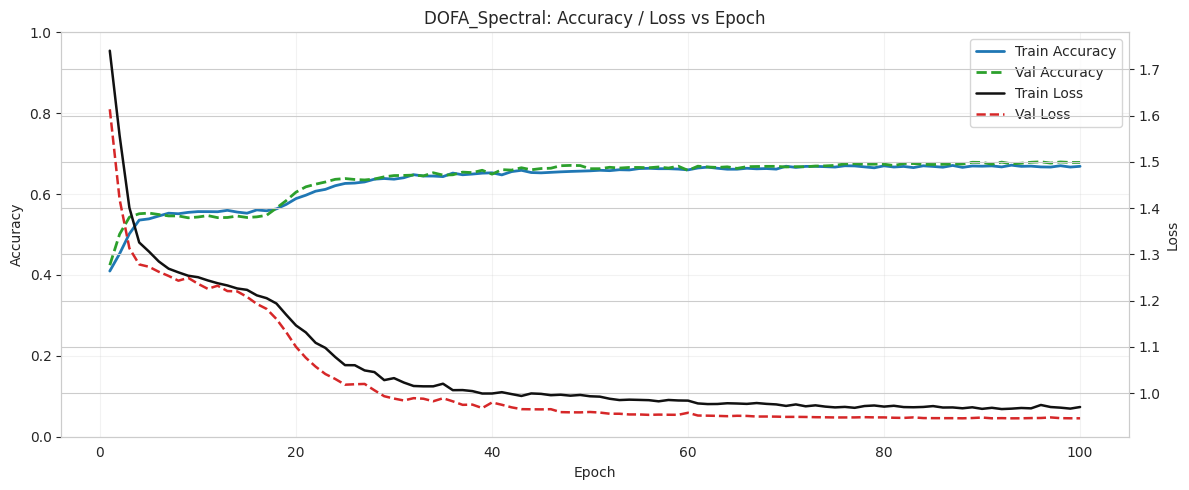

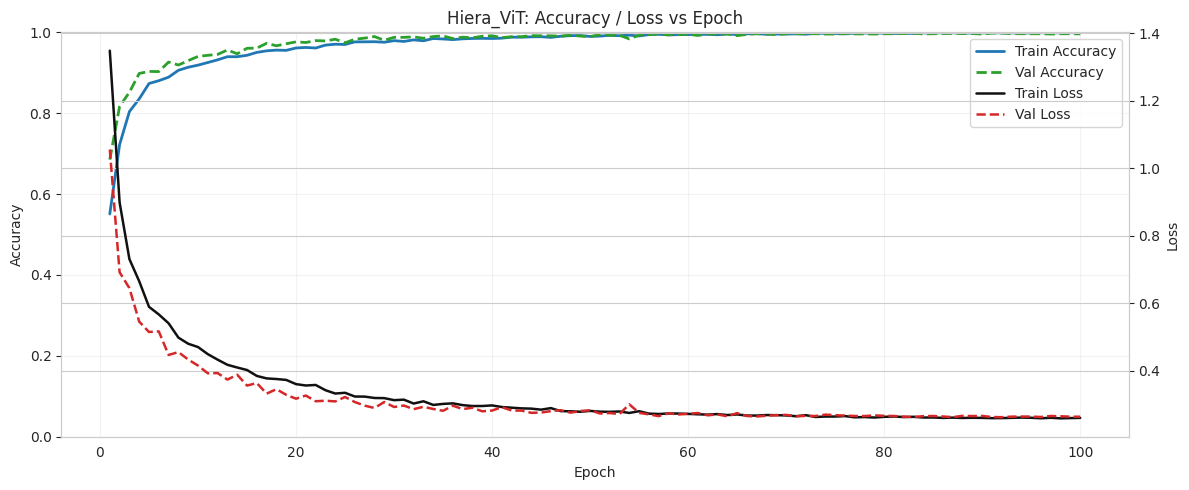

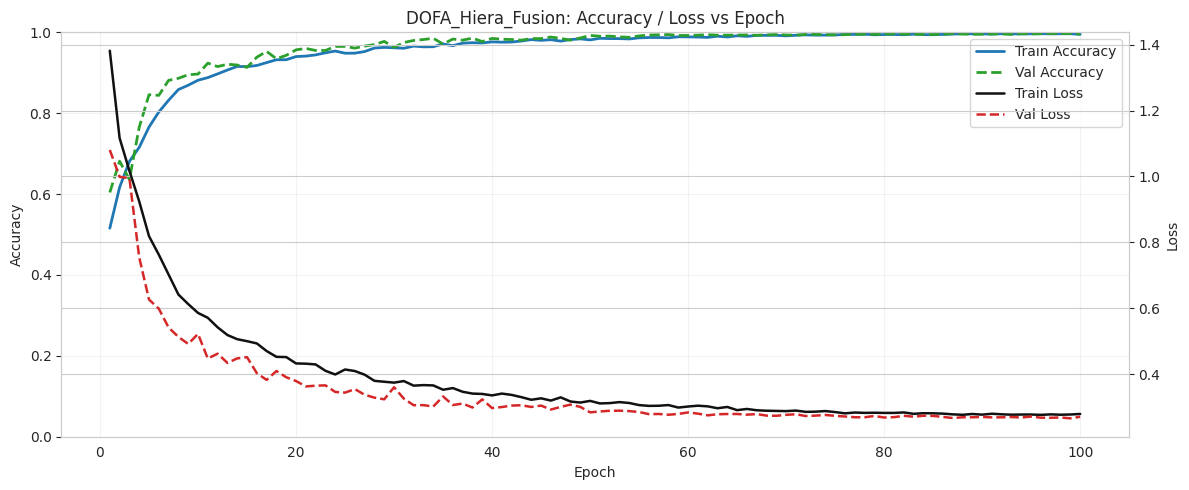

In [17]:
for model_name, artifact in model_artifacts.items():
    hist   = artifact["history"]
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(epochs, hist["accuracy"],     color="#1f77b4", linewidth=2,   label="Train Accuracy")
    ax1.plot(epochs, hist["val_accuracy"], color="#2ca02c", linewidth=2, linestyle="--", label="Val Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(epochs, hist["loss"],     color="#111111", linewidth=1.8,   label="Train Loss")
    ax2.plot(epochs, hist["val_loss"], color="#d62728", linewidth=1.8, linestyle="--", label="Val Loss")
    ax2.set_ylabel("Loss")

    lines  = ax1.get_lines() + ax2.get_lines()
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right", frameon=True)
    plt.title(f"{model_name}: Accuracy / Loss vs Epoch")
    plt.tight_layout()

    curve_path = PLOT_DIR / f"{model_name}_training_curves.png"
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    plt.show()

## 7.3 — Cross-model comparison bar charts

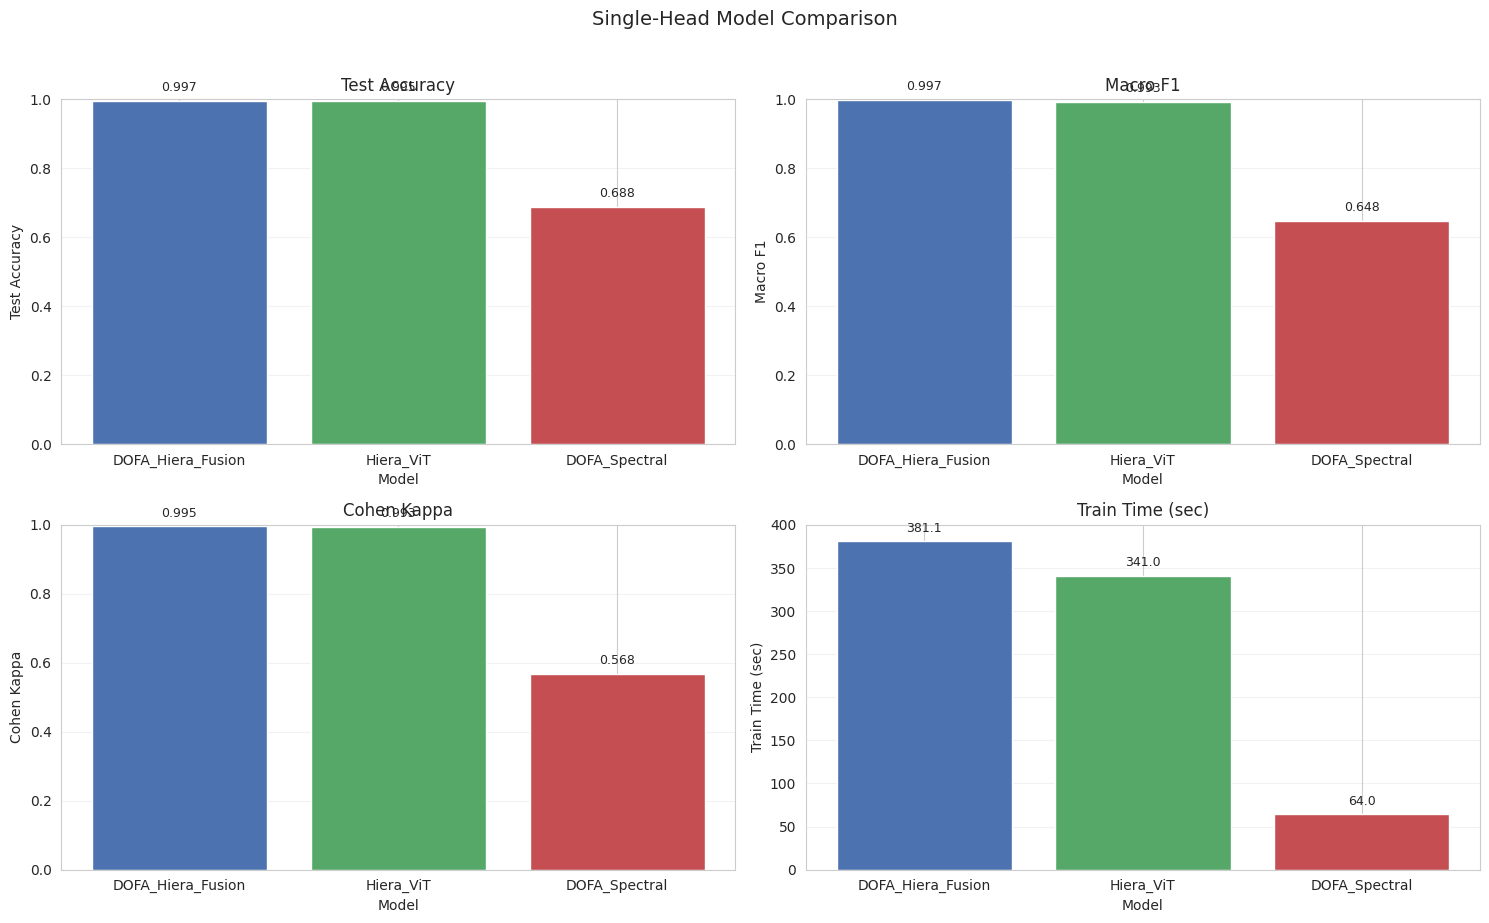

In [18]:
plot_df = summary_df[[
    "model", "test_accuracy", "macro_f1", "kappa", "train_time_sec",
    "test_nll", "test_brier", "test_ece_15bin",
]].copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes    = axes.flatten()
palette = ["#4c72b0", "#55a868", "#c44e52"]

metric_specs = [
    ("test_accuracy",  "Test Accuracy",   (0.0, 1.0), "{:.3f}"),
    ("macro_f1",       "Macro F1",        (0.0, 1.0), "{:.3f}"),
    ("kappa",          "Cohen Kappa",     (0.0, 1.0), "{:.3f}"),
    ("train_time_sec", "Train Time (sec)", None,       "{:.1f}"),
]

for ax, (col, title, ylim, fmt) in zip(axes, metric_specs):
    local = plot_df[["model", col]].copy()
    bars  = ax.bar(local["model"], local[col], color=palette[:len(local)])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.25)
    for patch in bars:
        height = patch.get_height()
        xpos   = patch.get_x() + patch.get_width() / 2
        offset = (ylim[1] - ylim[0]) * 0.02 if ylim else max(local[col].max() * 0.02, 0.05)
        ax.text(xpos, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=9)

plt.suptitle("Single-Head Model Comparison", y=1.02, fontsize=14)
plt.tight_layout()
comparison_path = PLOT_DIR / "model_comparison_metrics.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

## 7.4 — Calibration proxy metrics and confusion matrices

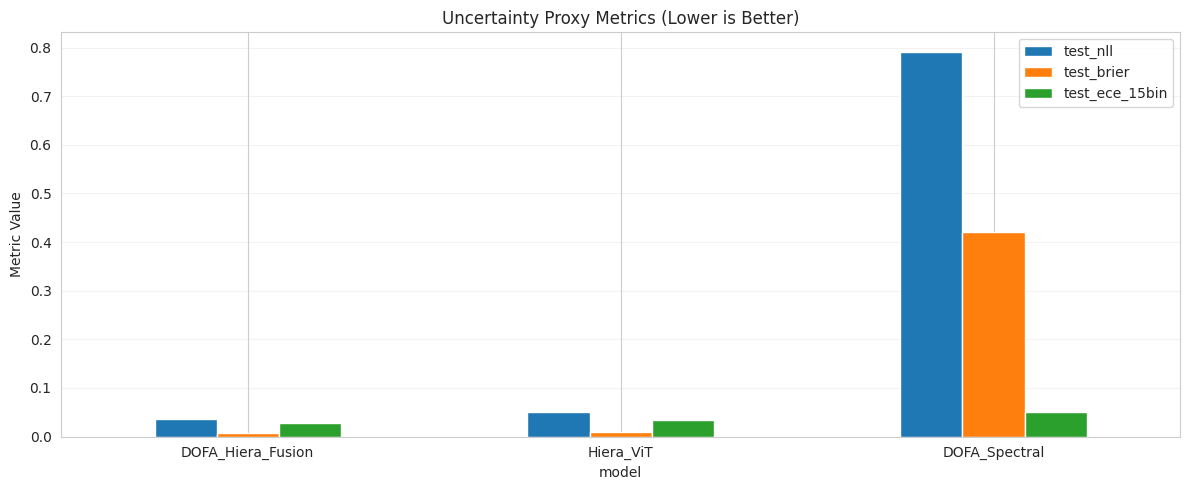

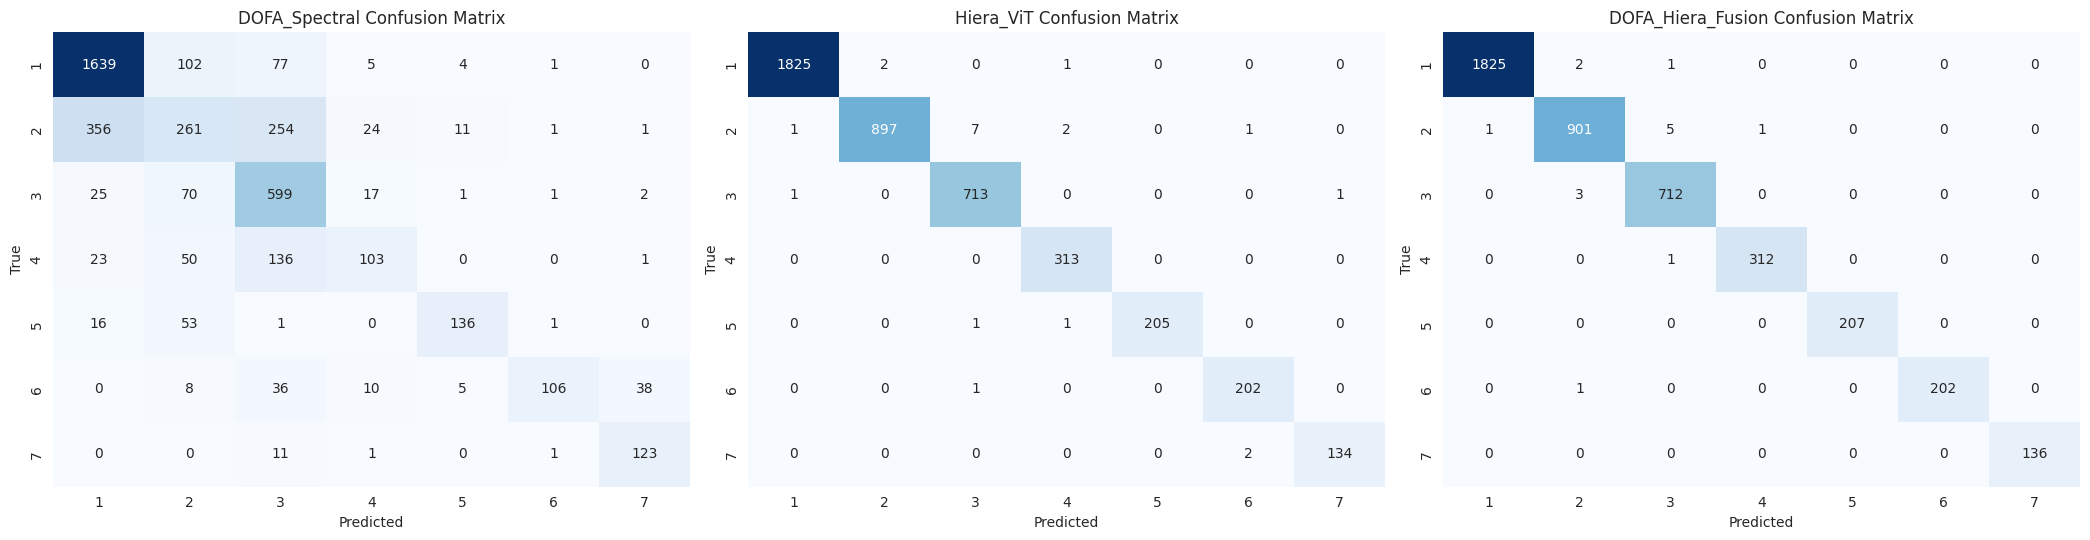

Saved confusion matrix figure: /content/drive/My Drive/Classification/dofa/results/training_plots/confusion_matrices_side_by_side.png
All training plots saved to: /content/drive/My Drive/Classification/dofa/results/training_plots


In [19]:
# Calibration proxy chart (lower is better for all three metrics)
fig, ax     = plt.subplots(figsize=(12, 5))
calib_cols  = ["test_nll", "test_brier", "test_ece_15bin"]
calib_df    = plot_df[["model"] + calib_cols].set_index("model")
calib_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Uncertainty Proxy Metrics (Lower is Better)")
ax.set_ylabel("Metric Value")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
calib_path = PLOT_DIR / "uncertainty_proxy_metrics.png"
plt.savefig(calib_path, dpi=200, bbox_inches="tight")
plt.show()

# Side-by-side confusion matrices
class_ticks = [str(i + 1) for i in range(num_classes)]
fig, axes   = plt.subplots(1, len(model_artifacts), figsize=(7 * len(model_artifacts), 5.5))
if len(model_artifacts) == 1:
    axes = [axes]

for ax, (model_name, artifact) in zip(axes, model_artifacts.items()):
    sns.heatmap(
        artifact["confusion_matrix"],
        annot=True, fmt="d", cmap="Blues",
        xticklabels=class_ticks, yticklabels=class_ticks,
        cbar=False, ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
cm_path = PLOT_DIR / "confusion_matrices_side_by_side.png"
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved confusion matrix figure:", cm_path)
print("All training plots saved to:", PLOT_DIR)

# 8.0 — Scene Visualisation
Load the saved best models, run dense patch-by-patch inference over the entire scene, and save classified maps as PNGs and an Excel workbook.

## 8.1 — Visualisation helpers

In [20]:
CUSTOM_OBJECTS = {
    "PatchExtractor":       PatchExtractor,
    "PatchPositionEncoder": PatchPositionEncoder,
    "DOFAWavelengthEmbed":  DOFAWavelengthEmbed,
}


def get_scene_rgb(x_img, bands):
    """Select three bands as an approximate RGB composite; clip to [0, 1]."""
    if bands >= 6:
        rgb_idx = [bands // 2 - 1, bands // 2, bands // 2 + 1]
    elif bands >= 3:
        rgb_idx = [0, 1, 2]
    else:
        raise ValueError(f"Need at least 3 bands to form RGB, got {bands}.")
    return np.clip(x_img[:, :, rgb_idx], 0.0, 1.0)


def get_display_cmap(num_classes):
    """Build a ListedColormap: index 0 = background black, 1..K = class colours."""
    return ListedColormap([BACKGROUND_COLOR] + CLASS_COLOR_BASE[:num_classes])


def predict_full_scene_labels(model, x_img, patch_size=9, batch_size=256):
    """Run dense sliding-window inference row-by-row; returns a (H, W) label map."""
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode="edge")
    preds = np.zeros((x_img.shape[0], x_img.shape[1]), dtype=np.int32)

    for r in range(x_img.shape[0]):
        row_patches = np.empty(
            (x_img.shape[1], patch_size, patch_size, x_img.shape[-1]),
            dtype=np.float32,
        )
        for c in range(x_img.shape[1]):
            row_patches[c] = x_pad[r:r + patch_size, c:c + patch_size, :]

        row_prob  = model.predict(row_patches, batch_size=batch_size, verbose=0)
        preds[r]  = np.argmax(row_prob, axis=1) + 1  # back to 1..K

    return preds


def load_saved_models_for_visualization(model_dir, custom_objects):
    """Attempt to load all three best models; return dicts of loaded and missing."""
    model_files = {
        "DOFA_Spectral":     model_dir / "DOFA_Spectral_best.keras",
        "Hiera_ViT":         model_dir / "Hiera_ViT_best.keras",
        "DOFA_Hiera_Fusion": model_dir / "DOFA_Hiera_Fusion_best.keras",
    }
    loaded, missing = {}, {}
    for model_key, model_path in model_files.items():
        if not model_path.exists():
            missing[model_key] = f"Missing file: {model_path}"
            continue
        try:
            loaded[model_key] = keras.models.load_model(
                model_path, custom_objects=custom_objects,
                compile=False, safe_mode=False,
            )
        except Exception as exc:
            missing[model_key] = f"Load failed: {exc}"
    return loaded, missing


def save_single_panel(image, title, save_path, cmap=None, vmin=None, vmax=None):
    """Save a single image panel as a high-DPI PNG."""
    fig, ax = plt.subplots(figsize=(8, 6))
    if cmap is None:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_combined_overview(rgb_image, y_true, pred_maps, missing_info, num_classes, save_path):
    """Save a five-panel side-by-side overview: RGB, GT, and one panel per model."""
    cmap   = get_display_cmap(num_classes)
    panels = [
        ("Approximate RGB",                       rgb_image,                            "rgb"),
        ("True Label Map",                        y_true,                               "label"),
        ("DOFA Spectral Initial Classification",  pred_maps.get("DOFA_Spectral"),       "label"),
        ("Hiera ViT Initial Classification",      pred_maps.get("Hiera_ViT"),           "label"),
        ("DOFA+Hiera Fusion Initial Classification", pred_maps.get("DOFA_Hiera_Fusion"), "label"),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(30, 7), sharex=True, sharey=True)
    for ax, (title, img, kind) in zip(axes, panels):
        ax.set_title(title, fontsize=13)
        if kind == "rgb":
            ax.imshow(img)
        elif img is None:
            ax.imshow(np.zeros_like(y_true), cmap=cmap, vmin=0, vmax=num_classes)
            key = {
                "DOFA Spectral": "DOFA_Spectral",
                "Hiera ViT": "Hiera_ViT",
                "DOFA+Hiera Fusion": "DOFA_Hiera_Fusion",
            }.get(
                next((k for k in ("DOFA Spectral", "Hiera ViT", "DOFA+Hiera Fusion") if k in title), None)
            )
            ax.text(0.5, 0.5, missing_info.get(key, "Unavailable"),
                    ha="center", va="center", fontsize=10, wrap=True, transform=ax.transAxes)
        else:
            ax.imshow(img, cmap=cmap, vmin=0, vmax=num_classes)
        ax.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, color=BACKGROUND_COLOR, label="Background")]
    for i in range(num_classes):
        handles.append(plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOR_BASE[i], label=f"Class {i+1}"))
    fig.legend(handles=handles, loc="lower center", ncol=min(num_classes + 1, 8),
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_images_to_excel(excel_path, image_paths, sheet_name="Initial_Classification_Maps"):
    """Embed PNG images into an Excel workbook at fixed anchor positions."""
    if excel_path.exists():
        wb = load_workbook(excel_path)
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]
        ws = wb.create_sheet(title=sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    anchors = ["A1", "J1", "A25", "J25", "A49", "J49"]
    for path, anchor in zip(image_paths, anchors):
        if path.exists():
            img        = XLImage(str(path))
            img.anchor = anchor
            ws.add_image(img)

    wb.save(excel_path)
    print("Saved Excel workbook:", excel_path)

## 8.2 — Generate and save all scene maps

In [21]:
scene_rgb    = get_scene_rgb(x_img, B)
display_cmap = get_display_cmap(num_classes)

loaded_models, missing_models = load_saved_models_for_visualization(MODEL_DIR, CUSTOM_OBJECTS)
prediction_maps = {}

for model_key, loaded_model in loaded_models.items():
    print(f"Generating full-scene classified image for {model_key}...")
    prediction_maps[model_key] = predict_full_scene_labels(
        loaded_model, x_img, patch_size=PATCH_SIZE, batch_size=BATCH_SIZE,
    )
    print(f"{model_key} map shape:", prediction_maps[model_key].shape)

if missing_models:
    print("Some models could not be loaded:")
    for model_key, reason in missing_models.items():
        print(f"  - {model_key}: {reason}")

# Individual PNG paths
rgb_png      = VIS_DIR / "scene_rgb.png"
gt_png       = VIS_DIR / "ground_truth_label_map.png"
dofa_png     = VIS_DIR / "DOFA_Spectral_initial_classification.png"
hiera_png    = VIS_DIR / "Hiera_ViT_initial_classification.png"
fusion_png   = VIS_DIR / "DOFA_Hiera_Fusion_initial_classification.png"
overview_png = VIS_DIR / "combined_initial_classification_overview.png"

save_single_panel(scene_rgb, "Approximate RGB", rgb_png)
save_single_panel(y_img, "Ground Truth Label Map", gt_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("DOFA_Spectral") is not None:
    save_single_panel(prediction_maps["DOFA_Spectral"], "DOFA Spectral Initial Classification",
                      dofa_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("Hiera_ViT") is not None:
    save_single_panel(prediction_maps["Hiera_ViT"], "Hiera ViT Initial Classification",
                      hiera_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("DOFA_Hiera_Fusion") is not None:
    save_single_panel(prediction_maps["DOFA_Hiera_Fusion"], "DOFA+Hiera Fusion Initial Classification",
                      fusion_png, cmap=display_cmap, vmin=0, vmax=num_classes)

save_combined_overview(
    rgb_image=scene_rgb, y_true=y_img, pred_maps=prediction_maps,
    missing_info=missing_models, num_classes=num_classes, save_path=overview_png,
)

image_paths_for_excel = [rgb_png, gt_png, dofa_png, hiera_png, fusion_png, overview_png]
save_images_to_excel(VIS_EXCEL_PATH, image_paths_for_excel, sheet_name="Initial_Classification_Maps")

print("All visualisation outputs saved to:", VIS_DIR)

Output hidden; open in https://colab.research.google.com to view.